In [4]:
import io, os, re
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import Counter
from collections import defaultdict
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [5]:
# load file
dir_path = "../"
stimuli_df = pd.read_excel(f"{dir_path}/scratch_plotting.xlsx", sheet_name = "TWs_for_table")

In [6]:
def extract_time_windows_by_study(data: pd.DataFrame, coord_col: str = 'component', study_col: str = 'study_id'):
    """
    Extracts time windows from a DataFrame column and tracks which study reported each.

    Parameters
    ----------
    data : pd.DataFrame
        Input data with at least two columns: study ID and time window strings (e.g., '100-200,300-400').
    coord_col : str
        Name of the column containing time window strings.
    study_col : str
        Name of the column containing study identifiers.

    Returns
    -------
    ms_to_studies : dict[int, set]
        Dictionary mapping milliseconds to sets of study IDs.
    n_studies : int
        Total number of unique studies.
    """
    pattern = r'(\d+)-(\d+)'
    ms_to_studies = defaultdict(set)

    for _, row in data.dropna(subset=[coord_col]).iterrows():
        study = row[study_col]
        matches = re.findall(pattern, str(row[coord_col]))
        for start, end in [(int(s), int(e)) for s, e in matches]:
            if end <= 1400:  # limit to 0–1400ms
                for t in range(start, end + 1):
                    ms_to_studies[t].add(study)

    n_studies = data[study_col].nunique()
    return ms_to_studies, n_studies


def compute_percentage_timeline(ms_to_studies: dict[int, set], n_studies: int, max_time: int = 1400) -> np.ndarray:
    """
    Converts the ms_to_studies dict into a timeline array of percentage values.

    Returns
    -------
    timeline : np.ndarray
        Array of percentages of studies for each millisecond from 0 to max_time.
    """
    return np.array([
        (len(ms_to_studies.get(t, set())) / n_studies) * 100
        for t in range(max_time + 1)
    ])


def plot_heatmap_timeline(timeline: np.ndarray, cmap, norm, save_path: str = None):
    """
    Plots a horizontal heatmap timeline of percentage of studies per millisecond.

    Parameters
    ----------
    timeline : np.ndarray
        Array of percentage values per millisecond.
    cmap : matplotlib.colors.Colormap
        Colormap to use for the heatmap.
    norm : matplotlib.colors.Normalize
        Normalization for color scaling.
    save_path : str, optional
        Path to save the figure. If None, the figure is not saved.
    """
    fig, ax = plt.subplots(figsize=(10, 3))

    for i in range(len(timeline)):
        ax.plot([i, i + 1], [1, 1], linestyle='-', linewidth=10, color=cmap(norm(timeline[i])))

    sm = ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.set_label('Percentage of Studies (%)')

    ax.set_yticks([])
    ax.set_title('Percentage of time windows reported in M/EEG studies')
    ax.set_xlabel('Time (ms)')
    ax.set_xlim(0, 1400)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved to: {save_path}")

    plt.show()

Saved to: ../meeg_timeline_heatmap.png


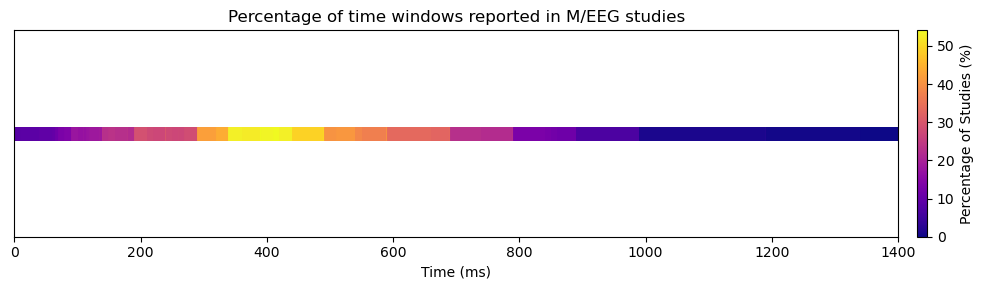

In [7]:
# extract study-to-ms mapping and total study count
ms_to_studies, n_studies = extract_time_windows_by_study(stimuli_df, 'component', 'study_id')

# compute timeline (percent coverage per ms)
timeline = compute_percentage_timeline(ms_to_studies, n_studies)

# we want the same color scale as figure 3
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

cmap = plt.colormaps['plasma']
#norm = Normalize(vmin=0, vmax=100)
norm = Normalize(vmin=timeline.min(), vmax=timeline.max())  # adaptive scale

# plot
save_path = os.path.join(dir_path, "meeg_timeline_heatmap.png")
plot_heatmap_timeline(timeline, cmap, norm, save_path=save_path)